# Sprint 9 - Tomando Decisões de Negócios Baseadas em Dados

## Projeto: Análise de um Teste A/B e Priorização de Hipóteses

## Introdução

Neste projeto será realizada uma análise de dados para apoiar a tomada de decisões de negócio em uma grande loja online.

O estudo será dividido em duas etapas principais: a **priorização de hipóteses** relacionadas ao aumento da receita e a **análise dos resultados de um teste A/B** realizado com os usuários da plataforma.

Na primeira etapa, serão utilizados os frameworks **ICE** e **RICE** para avaliar e priorizar as hipóteses propostas pelo departamento de marketing. A comparação entre os dois métodos permitirá compreender como a consideração do alcance dos usuários pode alterar a ordem de prioridade das iniciativas.

Na segunda etapa, serão analisados os resultados do teste A/B a partir de métricas como **receita acumulada, tamanho médio dos pedidos e taxa de conversão**. Também serão identificados valores atípicos e realizados testes estatísticos para verificar se as diferenças observadas entre os grupos são estatisticamente significativas.

O objetivo final é transformar os resultados obtidos em **evidências que possam apoiar uma decisão de negócio**, evitando conclusões baseadas apenas em variações aparentes ou em valores extremos presentes nos dados.

## 1. Priorização de Hipóteses

Nesta etapa, serão analisadas as nove hipóteses propostas pelo departamento de marketing com o objetivo de identificar quais apresentam maior potencial para aumentar a receita da loja online.

Para realizar essa priorização, serão aplicados dois frameworks de tomada de decisão:

- **ICE** — considera o impacto potencial da hipótese, o nível de confiança na estimativa e o esforço necessário para testá-la.
- **RICE** — acrescenta o alcance da hipótese aos critérios utilizados pelo ICE, permitindo considerar quantos usuários podem ser afetados pela iniciativa.

A aplicação dos dois métodos permitirá comparar os rankings e compreender como a inclusão do alcance dos usuários modifica a prioridade das hipóteses.

### Fórmulas utilizadas

**ICE:**

$$
ICE = \frac{Impact \times Confidence}{Effort}
$$

**RICE:**

$$
RICE = \frac{Reach \times Impact \times Confidence}{Effort}
$$

As hipóteses serão classificadas em ordem decrescente de pontuação em cada framework. Posteriormente, será realizada uma comparação entre os resultados para identificar quais hipóteses ganharam ou perderam prioridade quando o alcance foi incorporado à análise.

## 1.1 Preparação dos dados e cálculo do ICE

Primeiramente, será realizada a leitura do conjunto de dados contendo as hipóteses e seus respectivos indicadores de `Reach`, `Impact`, `Confidence` e `Effort`.

Como o arquivo utiliza ponto e vírgula (`;`) como separador, esse parâmetro será especificado durante a leitura dos dados.

Em seguida, será calculada a pontuação **ICE** para cada hipótese, relacionando o impacto esperado e o nível de confiança com o esforço necessário para testar a hipótese.

Quanto maior a pontuação ICE, maior será a prioridade da hipótese dentro desse framework.

In [1]:
import pandas as pd

hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

hypotheses['ICE'] = (
    hypotheses['Impact'] * hypotheses['Confidence']
) / hypotheses['Effort']

hypotheses = hypotheses.sort_values(by='ICE', ascending=False)

print(hypotheses[['Hypothesis', 'ICE']])

                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


## 1.2 Priorização das hipóteses pelo framework RICE

O framework RICE amplia o modelo ICE ao incorporar o alcance (`Reach`) de cada hipótese. Dessa forma, além do impacto, da confiança e do esforço necessário, considera-se também a quantidade de usuários que potencialmente serão afetados pela iniciativa.

A pontuação RICE será calculada pela fórmula:

$$
RICE = \frac{Reach \times Impact \times Confidence}{Effort}
$$

Quanto maior a pontuação RICE, maior será a prioridade da hipótese.

In [2]:
hypotheses['RICE'] = (
    hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']
) / hypotheses['Effort']

hypotheses = hypotheses.sort_values(by='RICE', ascending=False)

print(hypotheses[['Hypothesis', 'RICE']])

                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


## 1.3 Comparação entre as priorizações ICE e RICE

A aplicação dos frameworks ICE e RICE produziu diferenças relevantes na ordem de prioridade das hipóteses.

No ranking pelo ICE, as hipóteses com maior prioridade foram a promoção com descontos, a adição de novos canais de aquisição de tráfego e a inclusão de um formulário de assinatura nas páginas principais.

Quando o alcance dos usuários (`Reach`) foi incorporado ao cálculo do RICE, a ordem mudou. A hipótese de adicionar um formulário de assinatura às páginas principais passou para a primeira posição, seguida pela adição de blocos de recomendação de produtos. A hipótese de adicionar novos canais de aquisição ficou em terceiro lugar.

A principal razão para essas mudanças é que o RICE considera o alcance potencial de cada hipótese. Uma hipótese pode apresentar um impacto e uma confiança elevados, mas, se alcançar relativamente poucos usuários, sua pontuação será reduzida em comparação com uma hipótese que possa afetar uma parcela maior da base de usuários.

Por outro lado, hipóteses com grande alcance podem ganhar posições no ranking do RICE mesmo quando apresentam uma pontuação ICE menor. Isso demonstra que o RICE fornece uma perspectiva mais ampla para a priorização, pois considera não apenas o potencial da iniciativa, mas também quantos usuários poderão ser afetados por ela.

Assim, a utilização do RICE altera a priorização principalmente porque introduz a dimensão de alcance, permitindo direcionar os recursos para hipóteses que apresentam maior potencial de impacto sobre a base de usuários.

In [3]:
comparison = hypotheses[['Hypothesis', 'ICE', 'RICE']].copy()

comparison['ICE_rank'] = comparison['ICE'].rank(
    ascending=False,
    method='min'
)

comparison['RICE_rank'] = comparison['RICE'].rank(
    ascending=False,
    method='min'
)

comparison = comparison.sort_values(by='RICE_rank')

print(comparison)

                                          Hypothesis        ICE   RICE  \
7  Add a subscription form to all the main pages....  11.200000  112.0   
2  Add product recommendation blocks to the store...   7.000000   56.0   
0  Add two new channels for attracting traffic. T...  13.333333   40.0   
6  Show banners with current offers and sales on ...   8.000000   40.0   
8  Launch a promotion that gives users discounts ...  16.200000   16.2   
3  Change the category structure. This will incre...   1.125000    9.0   
1  Launch your own delivery service. This will sh...   2.000000    4.0   
5  Add a customer review page. This will increase...   1.333333    4.0   
4  Change the background color on the main page. ...   1.000000    3.0   

   ICE_rank  RICE_rank  
7       3.0        1.0  
2       5.0        2.0  
0       2.0        3.0  
6       4.0        3.0  
8       1.0        5.0  
3       8.0        6.0  
1       6.0        7.0  
5       7.0        7.0  
4       9.0        9.0  


## 1.4 Análise da mudança de priorização: ICE × RICE

A comparação entre os dois frameworks mostra que a inclusão do alcance (`Reach`) provocou mudanças importantes na ordem de prioridade das hipóteses.

A hipótese **"Add a subscription form to all the main pages"** passou da 3ª posição no ICE para a 1ª posição no RICE. Essa mudança ocorre porque, além de apresentar bons níveis de impacto e confiança, essa hipótese possui um alcance elevado, fazendo com que sua pontuação aumente significativamente quando o `Reach` é incorporado ao cálculo.

A hipótese **"Add product recommendation blocks to the store"** passou da 5ª posição no ICE para a 2ª posição no RICE. Novamente, o alcance elevado contribuiu para aumentar sua prioridade.

A hipótese **"Add two new channels for attracting traffic"** caiu da 2ª para a 3ª posição, enquanto **"Show banners with current offers and sales"** passou da 4ª para a 3ª posição. As duas hipóteses ficaram empatadas na pontuação RICE, com valor igual a 40.

A hipótese **"Launch a promotion that gives users discounts"**, que ocupava a 1ª posição no ICE, caiu para a 5ª posição no RICE. Apesar de apresentar a maior pontuação ICE, seu alcance é menor, o que reduz sua prioridade quando essa dimensão é considerada.

As demais hipóteses apresentaram alterações menores. A hipótese de mudança na estrutura das categorias passou da 8ª para a 6ª posição, enquanto o lançamento de um serviço próprio de entrega passou da 6ª para a 7ª posição. A hipótese relacionada à página de avaliações passou da 7ª para a 7ª posição, e a mudança da cor de fundo permaneceu na 9ª posição.

De forma geral, a comparação demonstra que o RICE favorece hipóteses capazes de atingir uma parcela maior dos usuários. Portanto, a principal diferença entre os rankings está na inclusão do alcance como fator de decisão, permitindo uma priorização que considera não apenas o impacto esperado e o esforço necessário, mas também a quantidade potencial de usuários afetados.

# 2. Análise do teste A/B

Nesta etapa, serão analisados os resultados de um teste A/B realizado com os usuários da loja online.

O objetivo é avaliar o comportamento dos grupos A e B a partir de métricas relacionadas à receita, ao tamanho médio dos pedidos e à taxa de conversão. Além da análise visual das métricas ao longo do tempo, serão investigados valores atípicos e realizadas análises estatísticas para verificar se as diferenças observadas entre os grupos são estatisticamente significativas.

A análise seguirá as seguintes etapas:

1. Preparação e validação dos dados do teste A/B;
2. Análise da receita acumulada por grupo;
3. Análise do tamanho médio acumulado dos pedidos;
4. Análise da diferença relativa no tamanho médio dos pedidos;
5. Análise da taxa de conversão diária e cumulativa;
6. Identificação de valores atípicos;
7. Testes estatísticos com os dados brutos;
8. Testes estatísticos após a remoção das anomalias;
9. Conclusão sobre os resultados do teste e recomendação para a tomada de decisão.

## 2.1 Preparação e pré-processamento dos dados

Antes de iniciar a análise do teste A/B, serão carregados os conjuntos de dados de pedidos e visitas.

Nesta etapa, serão verificadas as primeiras linhas e a estrutura das tabelas, além da conversão das colunas de data para o formato `datetime`. Essa preparação é necessária para permitir análises temporais, como o cálculo de métricas diárias e cumulativas.

Também será importante verificar posteriormente se existem usuários presentes simultaneamente nos grupos A e B, pois essa situação pode comprometer a independência dos grupos do teste.

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import datetime as dt
import matplotlib.pyplot as plt

orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

orders['date'] = orders['date'].map(
    lambda x: dt.datetime.strptime(x, '%Y-%m-%d')
)

visits['date'] = visits['date'].map(
    lambda x: dt.datetime.strptime(x, '%Y-%m-%d')
)

print(orders.head())
print(visits.head())

print(orders.info())
print(visits.info())

   transactionId   visitorId       date  revenue group
0     3667963787  3312258926 2019-08-15     30.4     B
1     2804400009  3642806036 2019-08-15     15.2     B
2     2961555356  4069496402 2019-08-15     10.2     A
3     3797467345  1196621759 2019-08-15    155.1     B
4     2282983706  2322279887 2019-08-15     40.5     B
        date group  visits
0 2019-08-01     A     719
1 2019-08-02     A     619
2 2019-08-03     A     507
3 2019-08-04     A     717
4 2019-08-05     A     756
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(

### 2.1.1 Verificação da distribuição dos usuários entre os grupos

Antes de analisar os resultados do teste A/B, é necessário verificar a consistência da divisão dos usuários entre os grupos.

Um mesmo usuário não deve participar simultaneamente dos grupos A e B, pois isso viola a independência esperada entre os grupos e pode distorcer a comparação das métricas.

Assim, serão identificados os usuários que aparecem nos dois grupos. Caso existam, esses usuários deverão ser removidos da análise.

In [5]:
# Identificar usuários presentes nos dois grupos
usersA = orders[orders['group'] == 'A']['visitorId']
usersB = orders[orders['group'] == 'B']['visitorId']

usersInBothGroups = set(usersA).intersection(set(usersB))

print('Usuários presentes nos dois grupos:', len(usersInBothGroups))

Usuários presentes nos dois grupos: 58


### Resultado da verificação dos grupos

A análise identificou 58 usuários presentes simultaneamente nos grupos A e B.

Essa situação representa um problema para a análise do teste A/B, pois o mesmo usuário não deveria participar dos dois grupos experimentais. Caso esses usuários fossem mantidos, seu comportamento poderia influenciar simultaneamente as métricas dos dois grupos, comprometendo a independência entre as amostras e podendo distorcer a comparação dos resultados.

Dessa forma, os 58 usuários identificados serão removidos dos dados de pedidos antes do cálculo das métricas do teste A/B.

Essa etapa é importante para garantir que a comparação entre os grupos seja realizada com amostras independentes e que as diferenças observadas posteriormente possam ser atribuídas com maior confiança ao experimento.

### 2.1.2 Remoção de usuários presentes nos dois grupos

Como foram identificados usuários que participaram simultaneamente dos grupos A e B, esses usuários serão excluídos da análise.

A remoção será realizada a partir dos seus identificadores (`visitorId`). Dessa forma, todos os pedidos associados a esses usuários serão retirados do conjunto de dados utilizado nas análises seguintes.

In [6]:
# Remover usuários presentes nos dois grupos
orders_filtered = orders[
    ~orders['visitorId'].isin(usersInBothGroups)
].copy()

print('Pedidos antes da filtragem:', len(orders))
print('Pedidos depois da filtragem:', len(orders_filtered))
print('Usuários removidos:', len(usersInBothGroups))

Pedidos antes da filtragem: 1197
Pedidos depois da filtragem: 1016
Usuários removidos: 58


### Resultado da filtragem

A filtragem removeu 58 usuários que estavam presentes simultaneamente nos grupos A e B. Como esses usuários estavam associados a 181 pedidos, o conjunto de dados passou de 1.197 para 1.016 pedidos.

A remoção é necessária para preservar a independência entre os grupos do teste A/B. A partir deste momento, `orders_filtered` será utilizado como a base de pedidos para as análises seguintes, enquanto o DataFrame original `orders` será mantido intacto como referência.

Com os dados preparados, podemos iniciar a análise das métricas do experimento.

## 2.2 Receita acumulada por grupo

Para avaliar a evolução da receita durante o teste A/B, será calculada a receita acumulada diariamente para cada grupo.

A análise da receita acumulada permite observar não apenas o desempenho em um determinado dia, mas também a evolução dos resultados ao longo de todo o período do experimento.

O objetivo é identificar diferenças relevantes entre os grupos, além de possíveis mudanças de comportamento, oscilações ou períodos em que um grupo passa a apresentar desempenho superior ao outro.

Para isso, serão agregados os pedidos por data e grupo e, posteriormente, calculada a receita acumulada ao longo do período do teste.

In [7]:
# Agregar a receita diária por grupo
dailyRevenue = (
    orders_filtered
    .groupby(['date', 'group'], as_index=False)
    .agg({'revenue': 'sum'})
)

# Calcular a receita acumulada para cada grupo
dailyRevenue['cumulativeRevenue'] = (
    dailyRevenue
    .groupby('group')['revenue']
    .cumsum()
)

# Separar os dados dos grupos A e B
cumulativeRevenueA = dailyRevenue[
    dailyRevenue['group'] == 'A'
][['date', 'cumulativeRevenue']]

cumulativeRevenueB = dailyRevenue[
    dailyRevenue['group'] == 'B'
][['date', 'cumulativeRevenue']]

### Gráfico da receita acumulada

O gráfico abaixo apresenta a evolução da receita acumulada dos grupos A e B ao longo do período do teste.

A comparação das curvas permite identificar qual grupo apresenta maior receita acumulada e observar possíveis mudanças de comportamento durante o experimento. Oscilações ou aumentos abruptos também podem indicar a presença de pedidos de valor excepcionalmente alto, que deverão ser investigados posteriormente como possíveis anomalias.

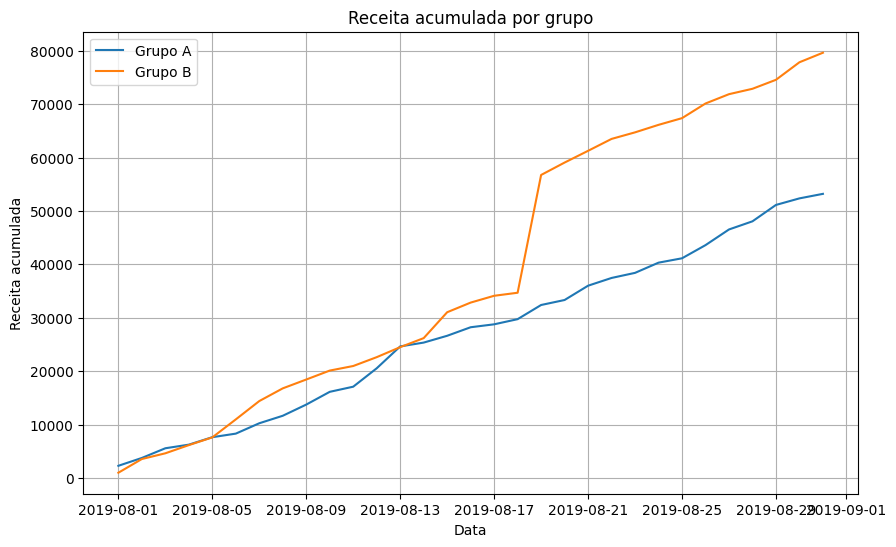

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    cumulativeRevenueA['date'],
    cumulativeRevenueA['cumulativeRevenue'],
    label='Grupo A'
)

plt.plot(
    cumulativeRevenueB['date'],
    cumulativeRevenueB['cumulativeRevenue'],
    label='Grupo B'
)

plt.title('Receita acumulada por grupo')
plt.xlabel('Data')
plt.ylabel('Receita acumulada')
plt.legend()
plt.grid()

plt.show()

### Análise da receita acumulada

O gráfico apresenta a evolução da receita acumulada dos grupos A e B ao longo do período do teste A/B.

No início do experimento, os dois grupos apresentam trajetórias relativamente próximas, com algumas oscilações. A partir de aproximadamente 19 de agosto, observa-se uma mudança significativa na trajetória do grupo B, que apresenta um aumento bastante acentuado na receita acumulada e passa a permanecer acima do grupo A durante o restante do período.

Esse crescimento abrupto sugere a presença de um ou mais pedidos de valor excepcionalmente elevado no grupo B. Como a receita acumulada incorpora cada novo pedido ao valor anterior, um pedido muito grande pode provocar um salto significativo na curva e manter a diferença entre os grupos mesmo nos dias seguintes.

Ao final do período analisado, o grupo B apresenta uma receita acumulada consideravelmente superior à do grupo A. Entretanto, essa diferença não deve ser interpretada imediatamente como evidência de que a estratégia do grupo B é superior. É necessário investigar a distribuição dos valores dos pedidos e identificar possíveis valores atípicos antes de concluir que o desempenho observado representa um comportamento normal dos usuários.

Portanto, a principal hipótese levantada a partir deste gráfico é que a vantagem do grupo B pode estar parcialmente relacionada à ocorrência de pedidos excepcionalmente altos. Essa hipótese será investigada nas próximas etapas da análise.

## 2.3 Tamanho médio acumulado do pedido por grupo

Nesta etapa, será analisada a evolução do tamanho médio acumulado dos pedidos nos grupos A e B ao longo do período do teste A/B.

A análise dessa métrica permite verificar se as diferenças observadas na receita acumulada estão relacionadas ao valor médio dos pedidos realizados pelos usuários de cada grupo.

O cálculo acumulado também permite observar a estabilidade dessa métrica ao longo do experimento e identificar possíveis alterações provocadas por pedidos de valor excepcionalmente elevado.

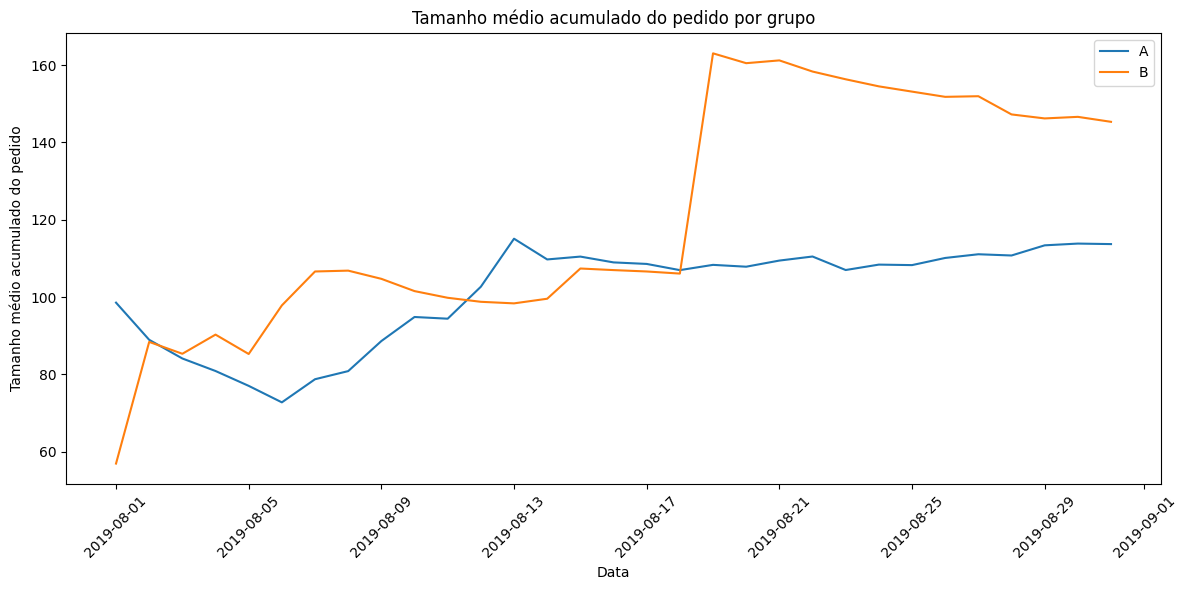

In [9]:
# Calculando a receita e a quantidade de pedidos acumulados por grupo
cumulativeOrders = (
    orders_filtered.groupby(['date', 'group'])
    .agg({'transactionId': 'nunique', 'revenue': 'sum'})
    .reset_index()
)

cumulativeOrders['orders'] = (
    cumulativeOrders.groupby('group')['transactionId'].cumsum()
)

cumulativeOrders['revenue'] = (
    cumulativeOrders.groupby('group')['revenue'].cumsum()
)

# Calculando o tamanho médio acumulado do pedido
cumulativeOrders['average_order'] = (
    cumulativeOrders['revenue'] / cumulativeOrders['orders']
)

# Separando os grupos
cumulativeA = cumulativeOrders[
    cumulativeOrders['group'] == 'A'
]

cumulativeB = cumulativeOrders[
    cumulativeOrders['group'] == 'B'
]

# Construindo o gráfico
plt.figure(figsize=(12, 6))

plt.plot(
    cumulativeA['date'],
    cumulativeA['average_order'],
    label='A'
)

plt.plot(
    cumulativeB['date'],
    cumulativeB['average_order'],
    label='B'
)

plt.title('Tamanho médio acumulado do pedido por grupo')
plt.xlabel('Data')
plt.ylabel('Tamanho médio acumulado do pedido')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Análise do tamanho médio acumulado do pedido

O gráfico mostra que o tamanho médio acumulado dos pedidos apresenta oscilações nos dois grupos ao longo do início do teste.

O grupo B começa com um valor médio inferior ao grupo A, mas passa rapidamente a apresentar valores superiores. Durante a primeira metade do período, as duas curvas oscilam e chegam a se aproximar, sem apresentar uma diferença estável entre os grupos.

A partir de aproximadamente 19 de agosto, observa-se um aumento acentuado no tamanho médio acumulado do pedido do grupo B, que passa de cerca de 107 para mais de 160. Esse movimento também é observado na receita acumulada e aumenta significativamente a diferença entre os grupos.

Após esse aumento, o tamanho médio acumulado do grupo B apresenta uma redução gradual, mas permanece acima do grupo A até o final do período. O grupo A, por sua vez, apresenta uma trajetória mais estável após as oscilações observadas no início do teste.

O comportamento observado indica que a diferença entre os grupos pode estar sendo influenciada por pedidos de valor elevado. No entanto, o gráfico, por si só, não permite determinar se esse efeito é decorrente de valores atípicos. Por isso, a análise dos percentis e dos pedidos anômalos será necessária para avaliar o impacto desses valores sobre os resultados do teste.

## 2.4 Diferença relativa no tamanho médio acumulado do pedido

Nesta etapa, será analisada a diferença relativa entre o tamanho médio acumulado dos pedidos dos grupos B e A.

Essa métrica permite avaliar quanto o tamanho médio acumulado do pedido do grupo B se distancia, proporcionalmente, do grupo A ao longo do período do teste.

A análise da diferença relativa complementa a comparação das médias acumuladas, permitindo observar com maior clareza em quais momentos o desempenho dos grupos se distancia e se essa diferença permanece estável ao longo do experimento.

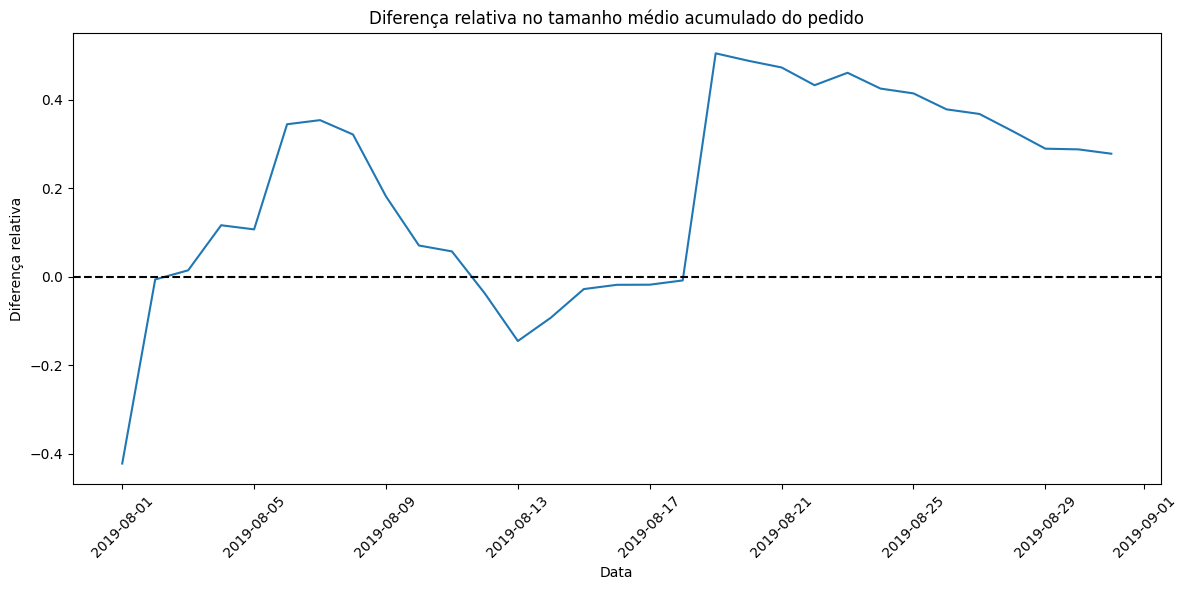

In [10]:
# Calculando a diferença relativa no tamanho médio acumulado do pedido
merged_cumulative_orders = cumulativeA.merge(
    cumulativeB,
    on='date',
    suffixes=['A', 'B']
)

relative_difference = (
    merged_cumulative_orders['average_orderB']
    / merged_cumulative_orders['average_orderA']
    - 1
)

plt.figure(figsize=(12, 6))

plt.plot(
    merged_cumulative_orders['date'],
    relative_difference
)

plt.axhline(y=0, color='black', linestyle='--')

plt.title('Diferença relativa no tamanho médio acumulado do pedido')
plt.xlabel('Data')
plt.ylabel('Diferença relativa')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Análise da diferença relativa no tamanho médio acumulado do pedido

A diferença relativa entre os grupos apresenta oscilações significativas ao longo do período do teste.

No início do experimento, o grupo B apresenta um tamanho médio acumulado inferior ao grupo A. Pouco depois, porém, a diferença passa a ser positiva e chega a aproximadamente 35%, indicando que, nesse momento, o tamanho médio acumulado dos pedidos do grupo B estava acima do grupo A.

Entre aproximadamente 9 e 14 de agosto, a diferença diminui e chega a ficar negativa, mostrando que, nesse intervalo, o tamanho médio acumulado dos pedidos do grupo B ficou abaixo do grupo A.

A partir de aproximadamente 15 de agosto, a diferença volta a ser positiva e permanece acima de zero. O ponto mais expressivo ocorre por volta de 19 de agosto, quando a diferença chega a aproximadamente 50%. Esse aumento coincide com o salto observado anteriormente na receita acumulada e no tamanho médio acumulado do grupo B.

Após esse pico, a diferença relativa diminui gradualmente, chegando a aproximadamente 28% no final do período. Apesar da redução, o grupo B permanece acima do grupo A.

As oscilações observadas, especialmente o aumento abrupto em 19 de agosto, indicam que pedidos de valor excepcionalmente elevado podem estar influenciando o resultado do grupo B. No entanto, o gráfico isoladamente não permite determinar a magnitude desse efeito.

Por isso, a análise dos valores atípicos será importante para verificar quanto dessa diferença permanece após a identificação e remoção das observações anômalas.

## 2.5 Taxa de conversão diária por grupo

Nesta etapa, será calculada a taxa de conversão diária de cada grupo do teste A/B.

A taxa de conversão será obtida dividindo o número de pedidos realizados em cada dia pelo número de visitantes do respectivo grupo no mesmo dia.

O objetivo é observar como a conversão se comporta diariamente ao longo do experimento e verificar possíveis oscilações ou diferenças entre os grupos. Como os valores diários podem apresentar variações, essa análise será complementada posteriormente pela análise da conversão cumulativa.

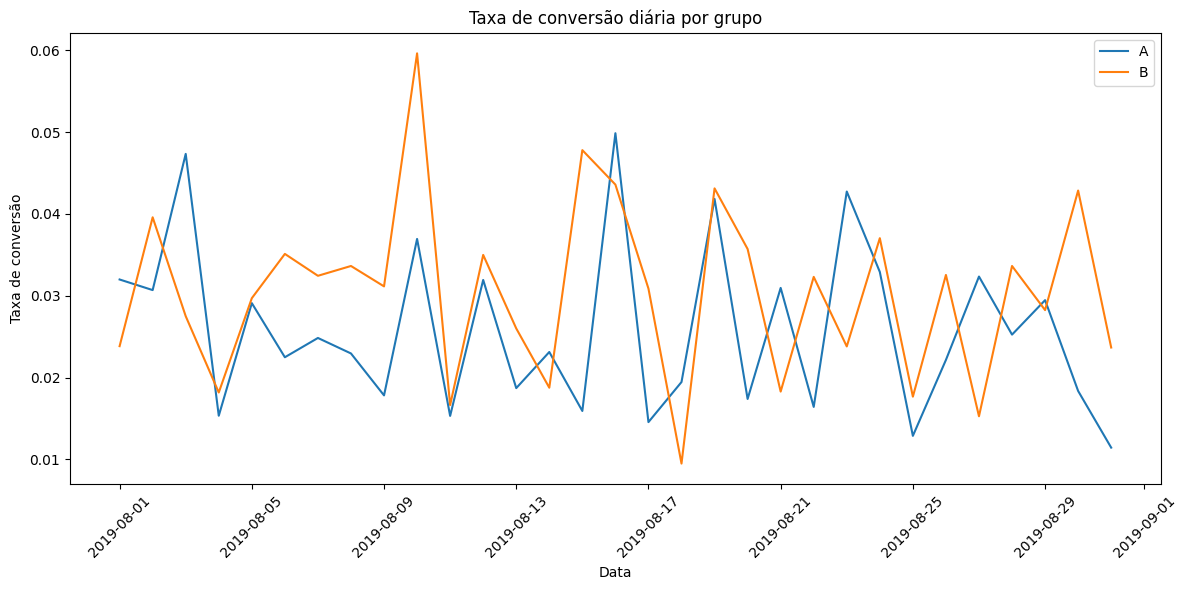

In [11]:
# Calculando a quantidade de pedidos por dia e por grupo
daily_orders = (
    orders_filtered
    .groupby(['date', 'group'])
    .agg({'transactionId': 'nunique'})
    .reset_index()
)

daily_orders.columns = ['date', 'group', 'orders']


# Calculando a quantidade de visitantes por dia e por grupo
daily_visitors = (
    visits
    .groupby(['date', 'group'])
    .agg({'visits': 'sum'})
    .reset_index()
)

daily_visitors.columns = ['date', 'group', 'visitors']


# Juntando pedidos e visitantes
daily_conversion = daily_orders.merge(
    daily_visitors,
    on=['date', 'group'],
    how='left'
)


# Calculando a taxa de conversão diária
daily_conversion['conversion'] = (
    daily_conversion['orders'] / daily_conversion['visitors']
)


# Separando os grupos
daily_conversion_a = daily_conversion[
    daily_conversion['group'] == 'A'
]

daily_conversion_b = daily_conversion[
    daily_conversion['group'] == 'B'
]


# Construindo o gráfico
plt.figure(figsize=(12, 6))

plt.plot(
    daily_conversion_a['date'],
    daily_conversion_a['conversion'],
    label='A'
)

plt.plot(
    daily_conversion_b['date'],
    daily_conversion_b['conversion'],
    label='B'
)

plt.title('Taxa de conversão diária por grupo')
plt.xlabel('Data')
plt.ylabel('Taxa de conversão')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Análise da taxa de conversão diária

O gráfico mostra uma variação considerável nas taxas de conversão diárias dos grupos A e B ao longo do período do teste. As duas séries apresentam oscilações frequentes, com alternância entre dias em que o grupo A apresenta maior conversão e dias em que o grupo B apresenta melhor desempenho.

O grupo B apresenta taxas de conversão superiores ao grupo A em diversos momentos, mas essa vantagem não se mantém de forma consistente ao longo de todo o período. Da mesma forma, o grupo A também apresenta alguns dias com taxas superiores às do grupo B.

As oscilações diárias indicam que a taxa de conversão pode variar bastante de um dia para outro, especialmente quando pequenas diferenças no número de pedidos resultam em mudanças mais expressivas na proporção de conversão.

Dessa forma, a análise da conversão diária permite visualizar a variabilidade do desempenho dos grupos ao longo do experimento, mas não é suficiente, isoladamente, para determinar se existe uma diferença estatisticamente significativa entre eles. Para essa conclusão, será necessário analisar a conversão acumulada e os testes estatísticos realizados nas etapas seguintes.

## 2.6 Diferença relativa na conversão cumulativa

Nesta etapa, será analisada a diferença relativa entre as taxas de conversão cumulativas dos grupos A e B.

A conversão cumulativa será calculada a partir da quantidade acumulada de pedidos dividida pela quantidade acumulada de visitantes de cada grupo.

A diferença relativa será calculada comparando a conversão cumulativa do grupo B com a do grupo A. Essa análise permite observar com maior clareza a evolução da diferença entre os grupos ao longo do teste e verificar se essa diferença tende a se estabilizar ou aumentar com o tempo.

Como os pedidos utilizados nesta etapa foram previamente filtrados para remover os usuários presentes nos dois grupos, a análise busca representar a diferença entre os grupos sem a contaminação identificada anteriormente.

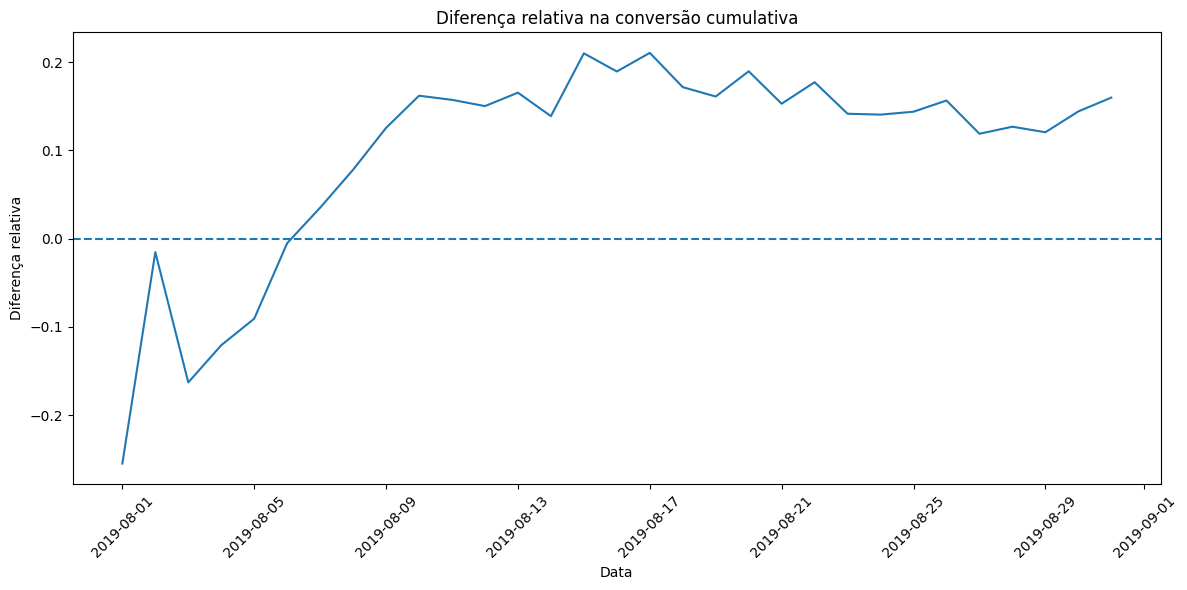

In [12]:
# Pedidos diários por grupo
daily_orders = (
    orders_filtered
    .groupby(['date', 'group'])['transactionId']
    .nunique()
    .reset_index()
)

daily_orders.columns = ['date', 'group', 'orders']


# Visitantes diários por grupo
daily_visitors = (
    visits
    .groupby(['date', 'group'])['visits']
    .sum()
    .reset_index()
)

daily_visitors.columns = ['date', 'group', 'visits']


# Calculando valores acumulados
daily_visitors = daily_visitors.sort_values(['group', 'date'])

daily_visitors['visits_cumulative'] = (
    daily_visitors
    .groupby('group')['visits']
    .cumsum()
)

daily_orders = daily_orders.sort_values(['group', 'date'])

daily_orders['orders_cumulative'] = (
    daily_orders
    .groupby('group')['orders']
    .cumsum()
)


# Juntando pedidos e visitantes
cumulative_conversion = daily_visitors[
    ['date', 'group', 'visits_cumulative']
].merge(
    daily_orders[
        ['date', 'group', 'orders_cumulative']
    ],
    on=['date', 'group'],
    how='left'
)


# Dias sem pedidos recebem zero
cumulative_conversion['orders_cumulative'] = (
    cumulative_conversion['orders_cumulative'].fillna(0)
)


# Calculando a conversão cumulativa
cumulative_conversion['conversion'] = (
    cumulative_conversion['orders_cumulative'] /
    cumulative_conversion['visits_cumulative']
)


# Separando os grupos
conversion_a = cumulative_conversion[
    cumulative_conversion['group'] == 'A'
]

conversion_b = cumulative_conversion[
    cumulative_conversion['group'] == 'B'
]


# Calculando a diferença relativa
relative_conversion = conversion_a[
    ['date', 'conversion']
].merge(
    conversion_b[
        ['date', 'conversion']
    ],
    on='date',
    suffixes=['A', 'B']
)

relative_conversion['relative_difference'] = (
    relative_conversion['conversionB'] /
    relative_conversion['conversionA'] - 1
)


# Gráfico
plt.figure(figsize=(12, 6))

plt.plot(
    relative_conversion['date'],
    relative_conversion['relative_difference']
)

plt.axhline(y=0, linestyle='--')

plt.title('Diferença relativa na conversão cumulativa')
plt.xlabel('Data')
plt.ylabel('Diferença relativa')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Análise da diferença relativa na conversão cumulativa

No início do teste, a diferença relativa na conversão cumulativa apresenta oscilações, alternando entre valores positivos e negativos. Isso indica que, nos primeiros dias, o grupo B ainda não apresentava uma vantagem consistente em relação ao grupo A.

A partir de aproximadamente 6 de agosto, a diferença passa a permanecer acima de zero e cresce gradualmente. Por volta de 15 de agosto, atinge seu maior valor, de aproximadamente 21%, indicando que a conversão cumulativa do grupo B estava cerca de 21% acima da do grupo A naquele momento.

Após esse pico, a diferença apresenta algumas oscilações e diminui gradualmente, mas permanece positiva durante o restante do período. No final do teste, o grupo B mantém uma vantagem de aproximadamente 16% em relação ao grupo A.

Diferentemente do comportamento observado no tamanho médio dos pedidos, a diferença na conversão cumulativa não apresenta um salto tão abrupto. A partir da segunda semana, o grupo B permanece consistentemente acima do grupo A, o que sugere uma possível vantagem do grupo B na proporção de visitantes que realizam pedidos.

Entretanto, a diferença observada no gráfico representa apenas uma diferença relativa e, por si só, não permite afirmar que o desempenho dos grupos seja estatisticamente diferente. Essa questão será verificada posteriormente por meio dos testes de significância estatística.

## 2.7 Identificação de anomalias no número de pedidos por usuário

Nesta etapa, serão calculados os percentis 95 e 99 para o número de pedidos realizados por cada usuário.

A análise desses percentis permitirá identificar valores que se afastam do comportamento observado para a maior parte dos usuários. Usuários com uma quantidade excepcionalmente elevada de pedidos poderão influenciar as métricas do teste A/B e, por isso, deverão ser considerados na etapa de filtragem dos dados.

O percentil 95 será utilizado como referência para identificar usuários com um número de pedidos acima do comportamento observado para a maior parte da amostra, enquanto o percentil 99 permitirá identificar valores ainda mais extremos.

Após o cálculo dos percentis, esses valores serão utilizados para definir um critério de identificação das anomalias e avaliar quais usuários deverão ser considerados na filtragem dos dados.

In [13]:
# Calculando o número de pedidos realizados por cada usuário
ordersByUsers = (
    orders_filtered.groupby('visitorId', as_index=False)
    .agg({'transactionId': 'nunique'})
)

ordersByUsers.columns = ['visitorId', 'orders']

# Calculando os percentis 95 e 99
percentiles = np.percentile(
    ordersByUsers['orders'],
    [95, 99]
)

print('Percentil 95:', percentiles[0])
print('Percentil 99:', percentiles[1])

Percentil 95: 1.0
Percentil 99: 2.0


### Análise dos percentis de pedidos por usuário

O percentil 95 indica que 95% dos usuários realizaram até 1 pedido, enquanto o percentil 99 indica que 99% dos usuários realizaram até 2 pedidos.

Esses resultados mostram que fazer mais de um pedido já é um comportamento pouco comum na amostra filtrada. Portanto, para evitar que usuários com comportamento excepcional influenciem as métricas do teste A/B, será considerado como anomalia um usuário que tenha realizado mais de 1 pedido.

Esse limite corresponde ao percentil 95 e será utilizado na etapa de filtragem dos dados.

## 2.8 Gráfico de dispersão dos preços dos pedidos

Nesta etapa, será analisada a distribuição dos valores individuais dos pedidos realizados durante o teste A/B.

O gráfico de dispersão permitirá visualizar a concentração dos pedidos em diferentes faixas de receita e identificar possíveis valores excepcionalmente elevados.

Essa análise é importante porque pedidos de valor muito superior ao padrão observado podem influenciar significativamente métricas como a receita acumulada e o tamanho médio dos pedidos. A identificação visual desses valores ajudará a avaliar a presença de possíveis anomalias antes da definição de um limite estatístico para a filtragem.

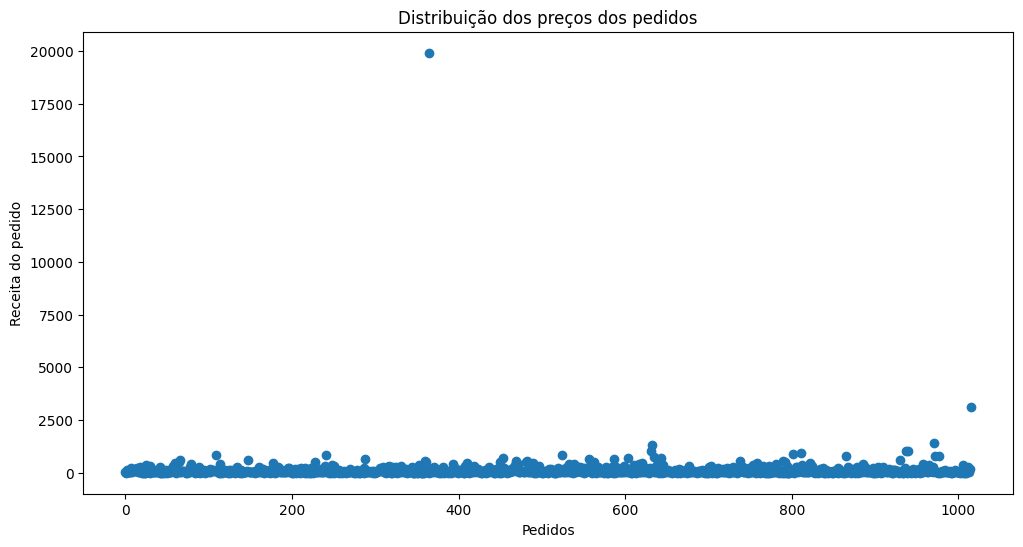

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.scatter(
    range(len(orders_filtered)),
    orders_filtered['revenue']
)

plt.title('Distribuição dos preços dos pedidos')
plt.xlabel('Pedidos')
plt.ylabel('Receita do pedido')

plt.show()

### Análise do gráfico de dispersão dos preços dos pedidos

O gráfico mostra que a maior parte dos pedidos apresenta valores de receita relativamente baixos e concentrados em uma faixa próxima à base da distribuição.

Também é possível identificar pedidos com valores excepcionalmente elevados em relação ao restante da amostra. Destaca-se especialmente um pedido de aproximadamente 19.920, muito distante da concentração principal dos dados, e um segundo pedido de aproximadamente 3.120, também destacado do grupo, embora bem menor que o primeiro.

Esses valores podem ser considerados possíveis anomalias, pois possuem uma diferença muito grande em relação aos demais pedidos e podem influenciar significativamente métricas como a receita acumulada e o tamanho médio dos pedidos.

Portanto, esses valores devem ser considerados na etapa de definição do limite para filtragem das anomalias antes da análise estatística final do teste A/B.

## 2.9 Identificação de anomalias nos preços dos pedidos

Nesta etapa, serão calculados os percentis 95 e 99 dos preços dos pedidos.

Assim como na análise do número de pedidos por usuário, esses percentis serão utilizados para identificar valores excepcionalmente elevados que possam distorcer as métricas do teste A/B.

O percentil 95 permitirá estabelecer um limite para os pedidos considerados atípicos, enquanto o percentil 99 ajudará a identificar valores ainda mais extremos. Esses limites serão utilizados posteriormente na filtragem dos dados para a análise estatística.

In [15]:
# Usando a base já filtrada, sem os usuários contaminados
orders = orders_filtered.copy()

# Calculando os percentis 95 e 99 dos preços dos pedidos
percentiles_revenue = np.percentile(
    orders['revenue'],
    [95, 99]
)

print('Percentil 95:', percentiles_revenue[0])
print('Percentil 99:', percentiles_revenue[1])

Percentil 95: 414.275
Percentil 99: 830.3


### Análise dos percentis dos preços dos pedidos

O percentil 95 indica que 95% dos pedidos possuem um valor de até 414,28, enquanto o percentil 99 indica que 99% dos pedidos possuem um valor de até aproximadamente 830,30.

Esses resultados indicam a presença de poucos pedidos com valores muito superiores ao comportamento predominante da amostra. Para a filtragem dos dados, será utilizado o percentil 95 como referência. Dessa forma, pedidos com valor superior a 414,28 serão considerados anômalos e removidos da análise estatística filtrada.

A utilização desse limite tem como objetivo reduzir a influência de pedidos excepcionalmente elevados sobre o tamanho médio dos pedidos e permitir uma comparação mais representativa do comportamento dos dois grupos.

## 2.10 Significância estatística da diferença na conversão com dados brutos

Nesta etapa, será verificado se a diferença observada na conversão entre os grupos A e B é estatisticamente significativa utilizando os dados brutos, ou seja, antes da remoção das anomalias identificadas nas etapas anteriores.

A análise estatística permitirá avaliar se a diferença observada entre os grupos pode representar um efeito real do teste A/B ou se pode ser explicada por variações aleatórias da amostra.

Será adotado um nível de significância de 5% (`alpha = 0.05`). Assim, se o valor de `p` for menor que 0,05, consideraremos que existe evidência estatística de uma diferença significativa na conversão entre os grupos. Caso contrário, não haverá evidência estatística suficiente para afirmar que as conversões são diferentes.

O resultado será posteriormente comparado com a análise realizada após a filtragem dos valores atípicos.

In [16]:
from scipy import stats
import numpy as np

# Número de pedidos por usuário em cada grupo
orders_by_users_a = (
    orders[orders['group'] == 'A']
    .groupby('visitorId')['transactionId']
    .nunique()
)

orders_by_users_b = (
    orders[orders['group'] == 'B']
    .groupby('visitorId')['transactionId']
    .nunique()
)

# Número total de visitantes em cada grupo
visitors_a = visits[visits['group'] == 'A']['visits'].sum()
visitors_b = visits[visits['group'] == 'B']['visits'].sum()

# Incluindo usuários que não fizeram pedidos
sample_a = pd.concat([
    orders_by_users_a,
    pd.Series(
        0,
        index=np.arange(
            visitors_a - len(orders_by_users_a)
        )
    )
])

sample_b = pd.concat([
    orders_by_users_b,
    pd.Series(
        0,
        index=np.arange(
            visitors_b - len(orders_by_users_b)
        )
    )
])

# Teste estatístico de Mann-Whitney
p_value = stats.mannwhitneyu(
    sample_a,
    sample_b
)[1]

# Taxas de conversão dos grupos
conversion_a = orders_by_users_a.sum() / visitors_a
conversion_b = orders_by_users_b.sum() / visitors_b

# Diferença relativa na conversão
relative_difference = conversion_b / conversion_a - 1

print('Conversão do grupo A:', conversion_a)
print('Conversão do grupo B:', conversion_b)
print('Diferença relativa:', relative_difference)
print('Valor-p:', p_value)

Conversão do grupo A: 0.02497865072587532
Conversão do grupo B: 0.02897018397124128
Diferença relativa: 0.1597977924896936
Valor-p: 0.011018084110014696


### Análise da significância estatística da diferença na conversão com dados brutos

O teste de Mann-Whitney indicou uma diferença estatisticamente significativa na conversão entre os grupos A e B, com valor-p de aproximadamente 0,011, abaixo do nível de significância de 5% adotado.

A conversão do grupo A foi de aproximadamente 2,50%, enquanto a do grupo B foi de aproximadamente 2,90%, representando uma diferença relativa de cerca de 16% a favor do grupo B.

Como o valor-p é menor que 0,05, rejeitamos a hipótese nula de que não há diferença na conversão entre os grupos. Há evidência estatística de que a conversão do grupo B é superior à do grupo A, considerando os dados brutos.

## 2.11 Significância estatística da diferença no tamanho médio do pedido com dados brutos

Nesta etapa, será verificado se existe uma diferença estatisticamente significativa no tamanho médio dos pedidos entre os grupos A e B utilizando os dados brutos.

Será aplicado o teste estatístico de Mann-Whitney para comparar a distribuição dos valores dos pedidos dos dois grupos. O nível de significância adotado será de 5% (`alpha = 0.05`).

Além do valor-p, será calculado o ganho relativo do grupo B em relação ao grupo A, permitindo avaliar a magnitude da diferença observada.

A análise será realizada antes da remoção das anomalias, de modo que seus resultados possam posteriormente ser comparados com aqueles obtidos utilizando os dados filtrados.

In [17]:
# Teste estatístico para comparar o tamanho médio dos pedidos
p_value = stats.mannwhitneyu(
    orders[orders['group'] == 'A']['revenue'],
    orders[orders['group'] == 'B']['revenue']
)[1]

# Tamanho médio dos pedidos
average_order_a = orders[orders['group'] == 'A']['revenue'].mean()
average_order_b = orders[orders['group'] == 'B']['revenue'].mean()

# Ganho relativo do grupo B
relative_gain = average_order_b / average_order_a - 1

print('Tamanho médio do pedido A:', average_order_a)
print('Tamanho médio do pedido B:', average_order_b)
print('Ganho relativo:', relative_gain)
print('Valor-p:', p_value)

Tamanho médio do pedido A: 113.70085470085469
Tamanho médio do pedido B: 145.34890510948907
Ganho relativo: 0.27834487693078414
Valor-p: 0.8622329690015668


### Análise da significância estatística da diferença no tamanho médio do pedido com dados brutos

O tamanho médio dos pedidos foi de aproximadamente 113,70 no grupo A e 145,35 no grupo B. Dessa forma, o grupo B apresentou um ganho relativo de aproximadamente 27,83% em relação ao grupo A.

Entretanto, o teste estatístico resultou em um valor-p de aproximadamente 0,862. Como esse valor é superior ao nível de significância de 5%, não há evidência estatística suficiente para rejeitar a hipótese de que não existe diferença entre os tamanhos médios dos pedidos dos grupos.

Portanto, embora o tamanho médio observado no grupo B seja superior ao do grupo A, essa diferença não é estatisticamente significativa nos dados brutos. A diferença observada pode ser explicada por variações aleatórias da amostra, especialmente considerando a presença de valores atípicos identificados anteriormente.

Esse resultado reforça a importância de realizar a mesma análise após a filtragem das anomalias, permitindo verificar se a conclusão permanece quando a influência dos pedidos excepcionalmente elevados é reduzida.

## 2.12 Significância estatística da diferença na conversão com dados filtrados

Nesta etapa, será repetido o teste estatístico da diferença na conversão entre os grupos A e B após a remoção das anomalias identificadas anteriormente.

Serão excluídos da análise os usuários que realizaram mais de 1 pedido ou que realizaram pelo menos um pedido com receita superior a 414,28, conforme os limites definidos a partir do percentil 95.

O objetivo é verificar se a diferença observada na conversão permanece estatisticamente significativa após a redução da influência dos valores atípicos.

Será utilizado novamente o teste de Mann-Whitney, considerando um nível de significância de 5% (`alpha = 0.05`). O resultado será comparado com aquele obtido utilizando os dados brutos.

In [18]:
# Identificando usuários com mais de 1 pedido
users_with_many_orders = (
    orders.groupby('visitorId')['transactionId']
    .nunique()
)

users_with_many_orders = users_with_many_orders[
    users_with_many_orders > percentiles[0]
].index

# Identificando usuários com pedidos acima do percentil 95
users_with_expensive_orders = orders[
    orders['revenue'] > percentiles_revenue[0]
]['visitorId']

# Combinando todos os usuários anômalos
abnormal_users = pd.concat([
    pd.Series(users_with_many_orders),
    users_with_expensive_orders
]).drop_duplicates()

# Removendo os usuários anômalos
filtered_orders = orders[
    ~orders['visitorId'].isin(abnormal_users)
]

# Número de pedidos por usuário após a filtragem
orders_by_users_a_filtered = (
    filtered_orders[filtered_orders['group'] == 'A']
    .groupby('visitorId')['transactionId']
    .nunique()
)

orders_by_users_b_filtered = (
    filtered_orders[filtered_orders['group'] == 'B']
    .groupby('visitorId')['transactionId']
    .nunique()
)

# Identificando quantos usuários anômalos pertenciam a cada grupo
abnormal_users_a = orders[
    (orders['group'] == 'A') &
    (orders['visitorId'].isin(abnormal_users))
]['visitorId'].nunique()

abnormal_users_b = orders[
    (orders['group'] == 'B') &
    (orders['visitorId'].isin(abnormal_users))
]['visitorId'].nunique()

# Incluindo usuários sem pedidos após a filtragem
sample_a_filtered = pd.concat([
    orders_by_users_a_filtered,
    pd.Series(
        0,
        index=np.arange(
            visitors_a
            - len(orders_by_users_a_filtered)
            - abnormal_users_a
        )
    )
])

sample_b_filtered = pd.concat([
    orders_by_users_b_filtered,
    pd.Series(
        0,
        index=np.arange(
            visitors_b
            - len(orders_by_users_b_filtered)
            - abnormal_users_b
        )
    )
])

# Teste estatístico de Mann-Whitney
p_value_filtered = stats.mannwhitneyu(
    sample_a_filtered,
    sample_b_filtered
)[1]

# Conversão após a filtragem
conversion_a_filtered = (
    orders_by_users_a_filtered.sum() / 
    (visitors_a - abnormal_users_a)
)

conversion_b_filtered = (
    orders_by_users_b_filtered.sum() /
    (visitors_b - abnormal_users_b)
)

# Diferença relativa na conversão
relative_difference_filtered = (
    conversion_b_filtered / conversion_a_filtered - 1
)

print('Conversão filtrada do grupo A:', conversion_a_filtered)
print('Conversão filtrada do grupo B:', conversion_b_filtered)
print('Diferença relativa:', relative_difference_filtered)
print('Valor-p:', p_value_filtered)

Conversão filtrada do grupo A: 0.021714713590415574
Conversão filtrada do grupo B: 0.025491546981822037
Diferença relativa: 0.17392968945597698
Valor-p: 0.01593020716573973


### Análise da significância estatística da diferença na conversão com dados filtrados

Após a remoção das anomalias, a taxa de conversão do grupo A foi de aproximadamente 2,17%, enquanto a do grupo B foi de aproximadamente 2,55%. Isso representa uma diferença relativa de aproximadamente 17,39% a favor do grupo B.

O teste estatístico resultou em um valor-p de aproximadamente 0,016. Como esse valor é inferior ao nível de significância de 5%, há evidência estatística suficiente para rejeitar a hipótese de que não existe diferença entre as taxas de conversão dos grupos.

Portanto, mesmo após a remoção dos valores considerados anômalos, o grupo B continua apresentando uma conversão estatisticamente superior à do grupo A.

Esse resultado é consistente com a análise realizada utilizando os dados brutos, na qual também foi identificada uma diferença estatisticamente significativa na conversão. Isso indica que a vantagem observada na conversão do grupo B não parece ser explicada apenas pelos valores atípicos presentes na amostra.

## 2.13 Significância estatística da diferença no tamanho médio do pedido com dados filtrados

Nesta etapa, será repetido o teste estatístico para comparar o tamanho médio dos pedidos entre os grupos A e B após a remoção das anomalias identificadas anteriormente.

Serão utilizados os dados filtrados, excluindo os usuários que realizaram mais de 2 pedidos e os pedidos com receita superior a 435,54.

O objetivo é verificar se a diferença observada no tamanho médio dos pedidos permanece estatisticamente significativa após a redução da influência dos valores atípicos.

Será aplicado novamente o teste de Mann-Whitney, considerando um nível de significância de 5% (`alpha = 0.05`). O resultado será comparado com aquele obtido utilizando os dados brutos.

In [19]:
# Teste estatístico para comparar o tamanho médio dos pedidos
p_value_filtered_order = stats.mannwhitneyu(
    filtered_orders[filtered_orders['group'] == 'A']['revenue'],
    filtered_orders[filtered_orders['group'] == 'B']['revenue']
)[1]

# Tamanho médio dos pedidos após a filtragem
average_order_a_filtered = (
    filtered_orders[filtered_orders['group'] == 'A']['revenue'].mean()
)

average_order_b_filtered = (
    filtered_orders[filtered_orders['group'] == 'B']['revenue'].mean()
)

# Diferença relativa no tamanho médio dos pedidos
relative_gain_filtered = (
    average_order_b_filtered / average_order_a_filtered - 1
)

print(
    'Tamanho médio do pedido A após a filtragem:',
    average_order_a_filtered
)

print(
    'Tamanho médio do pedido B após a filtragem:',
    average_order_b_filtered
)

print(
    'Diferença relativa:',
    relative_gain_filtered
)

print(
    'Valor-p:',
    p_value_filtered_order
)

Tamanho médio do pedido A após a filtragem: 80.74679802955666
Tamanho médio do pedido B após a filtragem: 78.05821205821206
Diferença relativa: -0.03329650261005346
Valor-p: 0.7711877309994826


### Análise da significância estatística da diferença no tamanho médio do pedido com dados filtrados

Após a remoção das anomalias, o tamanho médio dos pedidos foi de aproximadamente 80,75 no grupo A e 78,06 no grupo B. Dessa forma, o grupo B apresentou um tamanho médio aproximadamente 3,33% inferior ao grupo A.

O teste estatístico resultou em um valor-p de aproximadamente 0,771. Como esse valor é superior ao nível de significância de 5%, não há evidência estatística suficiente para afirmar que existe uma diferença significativa entre os grupos.

A comparação com os dados brutos é particularmente relevante: antes da filtragem, o grupo B apresentava um tamanho médio de pedido aproximadamente 27,83% superior ao grupo A. Após a remoção das anomalias, essa diferença desaparece e se inverte de sinal, sem significância estatística. Isso indica que a vantagem observada nos dados brutos era explicada, ao menos em parte, pelos pedidos de valor excepcionalmente elevado presentes na amostra.

## 2.14 Decisão sobre o teste A/B

Com base nos resultados obtidos ao longo da análise, será tomada a decisão final sobre o teste A/B.

A decisão considerará conjuntamente os resultados das métricas analisadas, os testes de significância estatística realizados com os dados brutos e filtrados e o impacto das anomalias identificadas durante a análise.

As três possibilidades previstas no projeto são:

1. Parar o teste e considerar um dos grupos como líder.
2. Parar o teste e concluir que não existe diferença entre os grupos.
3. Continuar o teste.

A decisão será baseada principalmente na significância estatística das diferenças observadas e na consistência dos resultados após a filtragem dos valores atípicos.

### Decisão sobre o teste A/B

A análise dos resultados indica um desempenho superior do grupo B principalmente em relação à taxa de conversão. Nos dados brutos, o grupo B apresentou uma conversão aproximadamente 15,98% superior à do grupo A, com diferença estatisticamente significativa (`p = 0,011`). Após a remoção dos valores atípicos, a diferença permaneceu estatisticamente significativa e aumentou para aproximadamente 17,39% (`p = 0,016`).

Esse resultado é relevante porque demonstra que a superioridade observada na conversão não parece estar associada exclusivamente à presença de usuários ou pedidos atípicos. Mesmo após a filtragem, o grupo B manteve uma taxa de conversão superior, indicando maior capacidade de transformar visitas em pedidos durante o período analisado.

Por outro lado, não foi identificada diferença estatisticamente significativa no tamanho médio dos pedidos. Embora os dados brutos apresentassem um valor médio aproximadamente 27,83% superior no grupo B, essa diferença deixou de existir e se inverteu de sinal após a remoção das anomalias. Nos dados filtrados, o tamanho médio dos pedidos foi de 80,75 no grupo A e 78,06 no grupo B, com valor-p de 0,771.

Dessa forma, os resultados sugerem que o principal efeito associado ao grupo B está relacionado à conversão, e não ao aumento do valor de cada pedido. Sob a perspectiva de negócio, isso indica que a estratégia representada pelo grupo B apresenta evidências de contribuir para um maior número de pedidos por visitante, enquanto não há evidência estatística de que tenha aumentado o valor médio das compras.

Considerando a consistência do resultado da conversão antes e depois da filtragem dos dados, recomenda-se **parar o teste e considerar o grupo B como líder**. A continuidade do experimento apresenta menor justificativa neste momento, uma vez que a principal diferença de desempenho já demonstrou significância estatística e permaneceu estável após o tratamento dos valores atípicos.

Ainda assim, a conclusão deve ser interpretada dentro do período e das condições específicas em que o teste foi realizado. A análise demonstra uma associação estatisticamente significativa entre a participação no grupo B e uma maior conversão, mas não permite afirmar, isoladamente, que o mesmo efeito ocorrerá com a mesma magnitude em outros períodos ou contextos de negócio.

# Conclusão geral

Este projeto permitiu aplicar uma abordagem orientada por dados para apoiar decisões de negócio em duas etapas complementares: a priorização de hipóteses de marketing e a avaliação de um teste A/B.

Na primeira etapa, a aplicação dos frameworks ICE e RICE demonstrou que a definição de prioridades pode mudar quando diferentes dimensões do negócio são incorporadas à análise. Enquanto o ICE considera impacto, confiança e esforço, o RICE acrescenta o alcance potencial da iniciativa. Como consequência, hipóteses com capacidade de atingir uma parcela maior dos usuários ganharam prioridade no ranking RICE. Essa comparação demonstra a importância de selecionar um framework de priorização coerente com o objetivo estratégico da organização.

Na segunda etapa, a análise do teste A/B mostrou uma diferença estatisticamente significativa na taxa de conversão entre os grupos. O grupo B apresentou uma conversão superior ao grupo A tanto nos dados brutos quanto após a remoção dos valores considerados anômalos. A consistência desse resultado reforça a evidência de que o desempenho superior do grupo B em conversão não é explicado exclusivamente pelos valores atípicos identificados na amostra.

Por outro lado, não foi encontrada diferença estatisticamente significativa no tamanho médio dos pedidos após a filtragem dos dados. Dessa forma, a principal vantagem observada no grupo B está associada à capacidade de gerar conversões, e não a um aumento comprovado no valor médio de cada pedido.

Com base no conjunto de evidências analisadas, a recomendação é interromper o teste e considerar o grupo B como líder. Do ponto de vista de negócio, os resultados fornecem suporte quantitativo para priorizar a estratégia associada ao grupo B, especialmente pelo efeito observado na conversão.

Por fim, o projeto demonstra a importância de combinar análise descritiva, identificação de anomalias e testes estatísticos antes de transformar diferenças observadas nos dados em decisões de negócio. Essa abordagem reduz o risco de decisões baseadas em variações aleatórias ou valores extremos e contribui para uma tomada de decisão de marketing mais fundamentada em evidências.